# EPFL Hackathon 2026 - Data Preprocesing

In [21]:
import numpy as np
import pandas as pd

from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.circuit.library import QAOAAnsatz
from qiskit_aer.primitives import Estimator
from qiskit_aer import Aer
from qiskit import transpile
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

## Synthetic Underwriting Dataset Generation and Interaction Graph Construction

This section generates a fully synthetic underwriting dataset designed to simulate a fraud detection environment with structured correlations.

The procedure follows six main steps:

1. **Latent Risk Sampling**  
   Entity-level latent risks are sampled for brokers, garages, and devices. These represent underlying fraud exposure patterns.

2. **Fraud Ring Simulation**  
   A fraction of cases are assigned to latent fraud rings that reuse small pools of entities, creating realistic correlation structures.

3. **Case Generation**  
   Each case is generated with:
   - Claim characteristics (type, amount, policy age, prior claims)
   - Assigned entities (broker, garage, device)
   - A network exposure score derived from latent entity risks

4. **Fraud Probability Modeling**  
   A pre-review fraud probability is computed using a logistic model based only on observable features and latent entity risks (no label leakage).

5. **Economic Modeling**  
   For each case:
   - `severity_L` = expected loss exposure  
   - `review_cost` = investigation cost  
   - `v_i` = expected net value of reviewing the case  

6. **Interaction Matrix Construction (W)**  
   A pairwise interaction matrix `W` is built to capture:
   - Shared entities (broker, garage, device, region/type)
   - Economic uplift from joint investigation
   - Evidence reinforcement (rarer links are stronger)
   - Redundancy penalties for highly similar cases  

The matrix is sparsified by keeping only the strongest edges to produce a realistic and computationally tractable interaction graph.

The final output consists of:
- A synthetic underwriting dataset (`underwriting_dataset.csv`)
- A sparse interaction matrix `W`
- A dataset and graph summary for inspection

# Dataset creation

In [22]:
import numpy as np
import pandas as pd

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def generate_underwriting_dataset_consistent(
    N=24,
    n_brokers=10,
    n_garages=12,
    n_regions=6,
    n_devices=40,
    n_rings=3,
    ring_fraction=0.35,
    seed=0,
):
    """
    Fully consistent synthetic dataset:
      - Latent entity risks (broker/garage/device) are sampled first
      - Cases sample entities (rings reuse entities)
      - p_fraud is computed from features + latent entity risks (no leakage)
      - severity_L uses leakage_by_type * claim_amount
      - v_i = alpha * p_fraud * severity_L - review_cost
      - w_ij is built from (shared entity links) * (economic uplift + cost sharing + evidence rarity) - redundancy
    """
    rng = np.random.default_rng(seed)

    # -----------------------
    # 1) Global parameters
    # -----------------------
    claim_types = np.array(["auto", "home", "health"])
    type_probs  = np.array([0.55, 0.30, 0.15])

    leakage_by_type = {"auto": 0.30, "home": 0.40, "health": 0.20}

    alpha_effectiveness = 0.55   # P(review catches/mitigates | problematic)
    hourly_cost = 60.0           # cost per hour of reviewer

    # Link strength weights (how strong each shared-entity signal is)
    rho = {
        "broker": 0.25,
        "garage": 0.50,
        "device": 0.60,
        "region_type": 0.15
    }

    # Synergy scaling
    kappa_uplift = 0.18   # scales "network uplift" in money
    mu_costshare = 0.50   # fraction of min(review_cost) you save by bundling
    pi_evidence  = 30.0   # evidence/prosecution bonus scale (rarer shared entities => larger)
    delta_redund = 0.25   # redundancy penalty scale

    # -----------------------
    # 2) Latent entity risks (no circularity)
    # -----------------------
    # These are fixed unknown propensities in the world (what the insurer has learned historically)
    broker_risk_latent = rng.normal(0.0, 0.35, size=n_brokers)
    garage_risk_latent = rng.normal(0.0, 0.45, size=n_garages)
    device_risk_latent = rng.normal(0.0, 0.30, size=n_devices)

    # -----------------------
    # 3) Fraud rings (latent structure that reuses entities)
    # -----------------------
    in_ring = rng.random(N) < ring_fraction
    ring_id_latent = np.zeros(N, dtype=int)
    ring_id_latent[in_ring] = rng.integers(1, n_rings + 1, size=in_ring.sum())

    # Each ring uses small pools of entities (creates correlation)
    def make_pool(n_total, frac):
        m = max(1, int(np.round(n_total * frac)))
        return rng.choice(n_total, size=m, replace=False)

    ring_broker_pool = {r: make_pool(n_brokers, 0.25) for r in range(1, n_rings+1)}
    ring_garage_pool = {r: make_pool(n_garages, 0.25) for r in range(1, n_rings+1)}
    ring_device_pool = {r: make_pool(n_devices, 0.30) for r in range(1, n_rings+1)}

    def pick_entity(ring, pool_dict, n_total, reuse_prob=0.80):
        if ring == 0:
            return int(rng.integers(0, n_total))
        # ring tends to reuse within pool
        if rng.random() < reuse_prob:
            return int(rng.choice(pool_dict[ring]))
        return int(rng.integers(0, n_total))

    # -----------------------
    # 4) Generate case-level features
    # -----------------------
    rows = []
    for i in range(N):
        ctype = str(rng.choice(claim_types, p=type_probs))
        region = int(rng.integers(0, n_regions))
        ring = int(ring_id_latent[i])

        # Claim amount: type-dependent lognormal (right-skewed)
        if ctype == "auto":
            amount = float(rng.lognormal(mean=8.2, sigma=0.55))   # ~ few k to ~20k
        elif ctype == "home":
            amount = float(rng.lognormal(mean=8.7, sigma=0.60))   # larger typical
        else:
            amount = float(rng.lognormal(mean=7.9, sigma=0.50))   # smaller typical

        policy_age_days = int(rng.integers(5, 3650))
        prior_claims = int(rng.poisson(0.6))

        complexity = float(np.clip(rng.normal(1.0, 0.35), 0.3, 2.0))
        review_minutes = int(np.clip(20 + 35 * complexity + 8 * prior_claims, 15, 120))

        broker = pick_entity(ring, ring_broker_pool, n_brokers)
        garage = pick_entity(ring, ring_garage_pool, n_garages)
        device = pick_entity(ring, ring_device_pool, n_devices)

        # Node-level network exposure score (from latent entity risks)
        # (No circularity: uses broker_risk_latent etc.)
        entity_risk_score = (
            0.30 * broker_risk_latent[broker] +
            0.45 * garage_risk_latent[garage] +
            0.25 * device_risk_latent[device]
        )

        # -----------------------
        # 5) Pre-review fraud probability p_fraud
        # -----------------------
        # Uses only "metadata" + latent entity risks + mild ring effect (rings are harder)
        # This is what your model would estimate automatically.
        log_amount = np.log(max(amount, 1.0))
        young_policy = 1.0 if policy_age_days < 60 else 0.0

        type_shift = {"auto": 0.15, "home": 0.05, "health": -0.05}[ctype]

        score = (
            -3.2
            + type_shift
            + 0.50 * (log_amount - 8.2)
            + 0.65 * young_policy
            + 0.35 * prior_claims
            + 0.85 * entity_risk_score
            + 0.55 * (1.0 if ring != 0 else 0.0)
        )
        p_fraud = float(sigmoid(score))

        rows.append({
            "case_id": i,
            "claim_type": ctype,
            "region_id": region,
            "claim_amount": amount,
            "policy_age_days": policy_age_days,
            "prior_claims": prior_claims,
            "complexity": complexity,
            "review_minutes": review_minutes,
            "broker_id": broker,
            "garage_id": garage,
            "device_id": device,
            "entity_risk_score": float(entity_risk_score),
            "p_fraud": p_fraud,
            "ring_id_latent": ring,
        })

    df = pd.DataFrame(rows)

    # -----------------------
    # 6) Economics: severity_L, review_cost, v_i
    # -----------------------
    df["severity_L"] = df.apply(
        lambda r: leakage_by_type[r["claim_type"]] * r["claim_amount"],
        axis=1
    )
    df["review_cost"] = (df["review_minutes"] / 60.0) * hourly_cost

    # Expected value of reviewing:
    # v_i = alpha * p_fraud * severity_L - review_cost
    df["v_i"] = alpha_effectiveness * df["p_fraud"] * df["severity_L"] - df["review_cost"]

    # -----------------------
    # 7) Pairwise synergy matrix W (w_ij)
    # -----------------------
    # Define:
    #   s_ij = combined link strength from shared entities (in [0,1])
    #   evidence bonus higher if shared entity is rare in this batch
    #   redundancy penalty if cases are "too similar" and low incremental info
    N = len(df)
    W = np.zeros((N, N), dtype=float)

    # rarity counts within the batch (simple proxy)
    broker_counts = df["broker_id"].value_counts().to_dict()
    garage_counts = df["garage_id"].value_counts().to_dict()
    device_counts = df["device_id"].value_counts().to_dict()

    def rarity_bonus(count):
        # fewer occurrences => higher bonus, bounded
        return float(np.clip(1.0 / max(count, 1), 0.02, 0.50))

    v = df["v_i"].to_numpy()
    c = df["review_cost"].to_numpy()

    # --- Calibration globale (rend W comparable à v) ---
    v_scale = np.percentile(np.abs(v), 75) + 1e-9
    c_scale = np.percentile(c, 75) + 1e-9

    alpha_synergy = 1.2 * v_scale      # force des synergies fortes
    beta_penalty  = 1.0 * v_scale      # pénalités significatives
    gamma_cost    = 0.6 * v_scale      # cost-sharing visible
    pi_evidence_strong = 2.5           # evidence amplifiée
    delta_redund_strong = 3.0          # forte pénalité redondance

    for i in range(N):
        for j in range(i+1, N):

            same_broker = df.loc[i, "broker_id"] == df.loc[j, "broker_id"]
            same_garage = df.loc[i, "garage_id"] == df.loc[j, "garage_id"]
            same_device = df.loc[i, "device_id"] == df.loc[j, "device_id"]
            same_region_type = (
                df.loc[i, "region_id"] == df.loc[j, "region_id"]
                and df.loc[i, "claim_type"] == df.loc[j, "claim_type"]
            )

            # --- Link strength s ---
            s = 1.0
            if same_broker:      s *= (1.0 - rho["broker"])
            if same_garage:      s *= (1.0 - rho["garage"])
            if same_device:      s *= (1.0 - rho["device"])
            if same_region_type: s *= (1.0 - rho["region_type"])
            s = 1.0 - s

            if s == 0.0:
                continue

            # --- Evidence bonus ---
            ev = 0.0
            if same_broker:
                ev += rarity_bonus(broker_counts[int(df.loc[i, "broker_id"])])
            if same_garage:
                ev += 1.5 * rarity_bonus(garage_counts[int(df.loc[i, "garage_id"])])
            if same_device:
                ev += 2.0 * rarity_bonus(device_counts[int(df.loc[i, "device_id"])])

            # --- Economic components ---
            vi = max(v[i], 0.0)
            vj = max(v[j], 0.0)

            uplift = np.sqrt(vi * vj) / (v_scale + 1e-9)
            cost_norm = min(c[i], c[j]) / (c_scale + 1e-9)

            # --- Synergy term (important) ---
            synergy = alpha_synergy * s * (
                0.8 * uplift +
                gamma_cost * cost_norm +
                pi_evidence_strong * ev
            )

            # --- Conflict / similarity penalty (important for combinatorial effect) ---
            conflict = 0.0
            if same_broker: conflict += 1.0
            if same_device: conflict += 1.2
            if same_garage: conflict += 0.8
            if same_region_type: conflict += 0.6

            penalty = beta_penalty * s * conflict

            # --- Strong redundancy penalty ---
            redundancy = 1.0 if (
                same_region_type and
                same_broker and
                abs(v[i] - v[j]) < 5.0 and
                max(vi, vj) < 20.0
            ) else 0.0

            redund_pen = delta_redund_strong * redundancy * v_scale

            # --- Final interaction ---
            wij = synergy - penalty - redund_pen

            W[i, j] = wij
            W[j, i] = wij

    lambda_factor = 0.1
    W = lambda_factor * W 

    # Optional sparsification: keep only strongest edges for realism & easier optimization
    edges = [(i, j, W[i, j]) for i in range(N) for j in range(i+1, N) if W[i, j] != 0.0]
    edges = sorted(edges, key=lambda x: abs(x[2]), reverse=True)
    keep_m = max(1, 2 * N)  # keep ~2N edges
    keep = set((i, j) for i, j, _ in edges[:keep_m])
    for i, j, _ in edges:
        if (i, j) not in keep:
            W[i, j] = 0.0
            W[j, i] = 0.0

    np.save("W.npy", W)
    return df, W

if __name__ == "__main__":
    df, W = generate_underwriting_dataset_consistent(N=24, seed=42)

    # >>> SAVE CSV HERE <<<
    df.to_csv("underwriting_dataset.csv", index=False)

    print(df.head(8)[[
        "case_id","claim_type","claim_amount","policy_age_days","prior_claims",
        "broker_id","garage_id","device_id","entity_risk_score","p_fraud",
        "severity_L","review_cost","v_i","ring_id_latent"
    ]])
    print("Non-zero edges in W:", int((np.abs(W) > 1e-12).sum() // 2))

   case_id claim_type  claim_amount  policy_age_days  prior_claims  broker_id  \
0        0       auto  18081.134056             1613             1          9   
1        1       auto   3369.652871             1604             2          3   
2        2       auto   4248.739891             2666             1          7   
3        3       auto  11738.840843             2027             2          3   
4        4       auto   1855.513637             3538             3          1   
5        5       auto   4027.007972             2727             1          0   
6        6       auto   8133.888356             2629             0          3   
7        7       auto   3826.943412              842             1          9   

   garage_id  device_id  entity_risk_score   p_fraud   severity_L  \
0         11         13          -0.142785  0.117113  5424.340217   
1          1         26           0.307181  0.106442  1010.895861   
2         11          9          -0.201575  0.057641  1274.6219

In [23]:
# 0) LOAD + SMALL BATCH
df = pd.read_csv("underwriting_dataset.csv")
df.columns = df.columns.str.strip()

v = df["v_i"].astype(float).to_numpy()
n = len(df)

# choose exactly K cases
K = min(5, n)
lam = 1.0

# penalty should dominate typical gains; start robustly
rho = 50.0 * max(1.0, np.max(np.abs(v)))  # scale with data magnitude

### Gridsearch

In [ ]:
def run_qaoa_once(v, W, K, lam, reps, rho_scale, shots, maxiter, seed=0):
    """
    Run one QAOA solve for the K-alert selection problem.
    Returns business score + run diagnostics.
    """
    t0 = time.time()
    n = len(v)

    # Scale penalty to strongly enforce sum(x)=K
    rho = rho_scale * max(1.0, float(np.max(np.abs(v))))

    # BUILD QUBO
    #   maximize  sum v_i x_i + lam * sum W_ij x_i x_j
    #   subject to sum x_i = K
    qp = QuadraticProgram("fraud_alert_prioritization")
    for i in range(n):
        qp.binary_var(f"x_{i}")  # x_i = 1 if alert i is selected

    linear = {}
    quadratic = {}

    def add_q(u, vname, c):
        key = tuple(sorted((u, vname)))
        quadratic[key] = quadratic.get(key, 0.0) + float(c)

    # (A) Individual value term
    for i in range(n):
        linear[f"x_{i}"] = linear.get(f"x_{i}", 0.0) - float(v[i])

    # (B) Network synergy term
    for i in range(n):
        for j in range(i + 1, n):
            wij = float(W[i, j])
            if wij != 0.0:
                add_q(f"x_{i}", f"x_{j}", -lam * wij)

    # (C) Exactly-K constraint via quadratic penalty
    for i in range(n):
        linear[f"x_{i}"] = linear.get(f"x_{i}", 0.0) + rho
        linear[f"x_{i}"] = linear.get(f"x_{i}", 0.0) - 2.0 * rho * K

    for i in range(n):
        for j in range(i + 1, n):
            add_q(f"x_{i}", f"x_{j}", 2.0 * rho)

    qp.minimize(linear=linear, quadratic=quadratic)
    qubo = QuadraticProgramToQubo().convert(qp)

    # QAOA OPTIMIZATION
    H, offset = qubo.to_ising()
    ansatz = QAOAAnsatz(cost_operator=H, reps=reps)

    estimator = Estimator()

    # Energy = expected Ising Hamiltonian
    def energy(theta):
        job = estimator.run([ansatz], [H], [theta])
        return float(job.result().values[0])

    # Random init of QAOA angles
    rng = np.random.default_rng(seed)
    theta0 = rng.uniform(0, 2*np.pi, size=ansatz.num_parameters)

    # Classical optimizer (hybrid loop)
    opt = minimize(energy, theta0, method="COBYLA", options={"maxiter": int(maxiter)})
    theta_star = opt.x

    # Sampling
    qc = ansatz.assign_parameters(theta_star)
    qc.measure_all()

    
    backend = Aer.get_backend("aer_simulator")
    tqc = transpile(qc, backend)
    counts = backend.run(tqc, shots=int(shots)).result().get_counts()

    # Decode and keep best feasible solution
    var_names = [var.name for var in qubo.variables]

    def decode(bitstring):
        # Reverse bit order to match x_0..x_{n-1}
        bits = np.array([int(b) for b in bitstring[::-1]], dtype=int)
        assign = dict(zip(var_names, bits))
        x = np.array([assign[f"x_{i}"] for i in range(n)], dtype=int)
        return x

    def score_business(x):
        # Business objective (no penalty)
        val = float(np.sum(v * x))
        syn = 0.0
        for i in range(n):
            for j in range(i + 1, n):
                syn += W[i, j] * x[i] * x[j]
        syn = float(syn)
        return val + lam * syn, val, syn

    best_feasible = None
    best_feasible_score = -1e18

    # Keep only solutions with exactly K selected alerts
    for bitstr, ct in counts.items():
        x = decode(bitstr)
        if int(x.sum()) == K:
            total, val, syn = score_business(x)
            if total > best_feasible_score:
                best_feasible_score = total
                best_feasible = (bitstr, x, val, syn)

    feasible_found = best_feasible is not None

    # Fallback: take most frequent if no feasible sampled
    if not feasible_found:
        best_bitstr = max(counts, key=counts.get)
        x = decode(best_bitstr)
        total, val, syn = score_business(x)
    else:
        best_bitstr, x, val, syn = best_feasible
        total = val + lam * syn

    selected_idx = np.where(x == 1)[0]
    runtime = time.time() - t0

    # Return all metrics 
    return {
        "total": float(total),
        "val": float(val),
        "syn": float(syn),
        "rho": float(rho),
        "reps": int(reps),
        "rho_scale": float(rho_scale),
        "shots": int(shots),
        "maxiter": int(maxiter),
        "seed": int(seed),
        "feasible_found": bool(feasible_found),
        "selected_count": int(x.sum()),
        "best_bitstring": best_bitstr,
        "selected_idx": selected_idx.tolist(),
        "runtime_s": float(runtime),
    }

In [ ]:
# GRID SEARCH hyperparams

reps_grid      = [2, 3]
rho_scale_grid = [5, 10, 20, 30, 50]     
shots_grid     = [6000, 8000, 10000]      
maxiter_grid   = [100]

results = []
run_id = 0

for reps in reps_grid:
    for rho_scale in rho_scale_grid:
        for shots in shots_grid:
            for maxiter in maxiter_grid:
                run_id += 1
                out = run_qaoa_once(
                    v=v, W=W, K=K, lam=lam,
                    reps=reps, rho_scale=rho_scale,
                    shots=shots, maxiter=maxiter,
                    seed=run_id  # change seed per run
                )
                results.append(out)
                print(f"[{run_id}] reps={reps} rho_scale={rho_scale} shots={shots} maxiter={maxiter} "
                      f"-> total={out['total']:.3f}, feasible={out['feasible_found']}, time={out['runtime_s']:.2f}s")

res_df = pd.DataFrame(results)

# Best config by business total
best_row = res_df.sort_values("total", ascending=False).iloc[0]
print("\n=== BEST CONFIG ===")
print(best_row[["total","val","syn","reps","rho_scale","rho","shots","maxiter","feasible_found","selected_count","runtime_s"]])
print("Selected idx:", best_row["selected_idx"])
print("Bitstring:", best_row["best_bitstring"])

[1] reps=2 rho_scale=5 shots=6000 maxiter=100 -> total=1251.895, feasible=True, time=54.76s
[2] reps=2 rho_scale=5 shots=8000 maxiter=100 -> total=1337.737, feasible=True, time=54.30s
[3] reps=2 rho_scale=5 shots=10000 maxiter=100 -> total=1187.658, feasible=True, time=56.03s
[4] reps=2 rho_scale=10 shots=6000 maxiter=100 -> total=992.086, feasible=True, time=54.93s
[5] reps=2 rho_scale=10 shots=8000 maxiter=100 -> total=1433.582, feasible=True, time=59.22s
[6] reps=2 rho_scale=10 shots=10000 maxiter=100 -> total=1834.738, feasible=True, time=57.19s
[7] reps=2 rho_scale=20 shots=6000 maxiter=100 -> total=1011.795, feasible=True, time=59.27s
[8] reps=2 rho_scale=20 shots=8000 maxiter=100 -> total=900.753, feasible=True, time=60.13s
[9] reps=2 rho_scale=20 shots=10000 maxiter=100 -> total=1327.872, feasible=True, time=59.77s
[10] reps=2 rho_scale=30 shots=6000 maxiter=100 -> total=773.944, feasible=True, time=54.11s
[11] reps=2 rho_scale=30 shots=8000 maxiter=100 -> total=1071.147, feasible=True, time=67.59s
[12] reps=2 rho_scale=30 shots=10000 maxiter=100 -> total=841.530, feasible=True, time=58.68s
[13] reps=2 rho_scale=50 shots=6000 maxiter=100 -> total=1473.723, feasible=True, time=54.41s
[14] reps=2 rho_scale=50 shots=8000 maxiter=100 -> total=989.491, feasible=True, time=57.25s
[15] reps=2 rho_scale=50 shots=10000 maxiter=100 -> total=1376.648, feasible=True, time=56.46s
[16] reps=3 rho_scale=5 shots=6000 maxiter=100 -> total=991.785, feasible=True, time=111.43s
[17] reps=3 rho_scale=5 shots=8000 maxiter=100 -> total=1597.735, feasible=True, time=128.09s
[18] reps=3 rho_scale=5 shots=10000 maxiter=100 -> total=1320.837, feasible=True, time=109.97s
[19] reps=3 rho_scale=10 shots=6000 maxiter=100 -> total=1601.716, feasible=True, time=114.37s
[20] reps=3 rho_scale=10 shots=8000 maxiter=100 -> total=681.918, feasible=True, time=111.28s
[21] reps=3 rho_scale=10 shots=10000 maxiter=100 -> total=1091.686, feasible=True, time=120.00s
[22] reps=3 rho_scale=20 shots=6000 maxiter=100 -> total=1232.321, feasible=True, time=114.54s
[23] reps=3 rho_scale=20 shots=8000 maxiter=100 -> total=969.470, feasible=True, time=116.15s
[24] reps=3 rho_scale=20 shots=10000 maxiter=100 -> total=1509.354, feasible=True, time=111.64s
[25] reps=3 rho_scale=30 shots=6000 maxiter=100 -> total=1518.118, feasible=True, time=124.77s
[26] reps=3 rho_scale=30 shots=8000 maxiter=100 -> total=1180.504, feasible=True, time=116.51s
[27] reps=3 rho_scale=30 shots=10000 maxiter=100 -> total=1132.040, feasible=True, time=111.38s
[28] reps=3 rho_scale=50 shots=6000 maxiter=100 -> total=1389.349, feasible=True, time=115.09s
[29] reps=3 rho_scale=50 shots=8000 maxiter=100 -> total=1302.254, feasible=True, time=112.43s
[30] reps=3 rho_scale=50 shots=10000 maxiter=100 -> total=1736.732, feasible=True, time=116.24s

=== BEST CONFIG ===
total             1834.738135
val               1237.322846
syn                597.415289
reps                        2
rho_scale                10.0
rho               5282.204691
shots                   10000
maxiter                   100
feasible_found           True
selected_count              5
runtime_s           57.193613
Name: 5, dtype: object
Selected idx: [0, 2, 3, 10, 18]
Bitstring: 000001000000010000001101


In [ ]:
# BEST CONFIG
best_params = {
    "reps": int(best_row["reps"]),
    "rho_scale": float(best_row["rho_scale"]),
    "shots": int(best_row["shots"]),
    "maxiter": int(best_row["maxiter"]),
    "seed": int(best_row["seed"]) if "seed" in best_row else 0,
}

# SHORT GRID SEARCH on lam with fix best_params
lam_grid = [0.0, 0.1, 0.3, 0.5, 1.0, 2.0]
lam_results = []

for t, lam_test in enumerate(lam_grid, start=1):
    out = run_qaoa_once(
        v=v, W=W, K=K, lam=lam_test,
        reps=best_params["reps"],
        rho_scale=best_params["rho_scale"],
        shots=best_params["shots"],
        maxiter=best_params["maxiter"],
        seed=best_params["seed"] + 1000 + t,
    )
    out["lam"] = float(lam_test)
    lam_results.append(out)
    print(f"[lam {t}] lam={lam_test} -> total={out['total']:.3f}, feasible={out['feasible_found']}")

lam_df = pd.DataFrame(lam_results)
best_lam_row = lam_df.sort_values("total", ascending=False).iloc[0]
lam = float(best_lam_row["lam"])  # <-- use best lam for final run

print("\n=== BEST lam (fixed best_params) ===")
print(best_lam_row[["lam","total","val","syn","reps","rho_scale","rho","shots","maxiter","feasible_found","selected_count","runtime_s"]])
print("Selected idx:", best_lam_row["selected_idx"])
print("Bitstring:", best_lam_row["best_bitstring"])

In [ ]:

v = df["v_i"].astype(float).to_numpy()
n = len(df)

# choose exactly K cases
K = min(5, n)
lam = 1.0

# penalty should dominate typical gains; start robustly
rho = 50.0 * max(1.0, np.max(np.abs(v))) 

#### Qubo builing

In [24]:
# BUILD QUBO 
qp = QuadraticProgram("fraud_alert_prioritization")

for i in range(n):
    qp.binary_var(f"x_{i}")

linear = {}
quadratic = {}

def add_q(u, vname, c):
    key = tuple(sorted((u, vname)))
    quadratic[key] = quadratic.get(key, 0.0) + float(c)

# (A) -sum v_i x_i
for i in range(n):
    linear[f"x_{i}"] = linear.get(f"x_{i}", 0.0) - float(v[i])

# (B) -lam * sum_{i<j} W_ij x_i x_j
for i in range(n):
    for j in range(i + 1, n):
        if W[i, j] != 0.0:
            add_q(f"x_{i}", f"x_{j}", -lam * float(W[i, j]))

# (C) rho*(sum x - K)^2
# Expand: rho*(sum x)^2 - 2*rho*K*(sum x) + const
# and (sum x)^2 = sum x_i + 2*sum_{i<j} x_i x_j
for i in range(n):
    linear[f"x_{i}"] = linear.get(f"x_{i}", 0.0) + rho
    linear[f"x_{i}"] = linear.get(f"x_{i}", 0.0) - 2.0 * rho * K

for i in range(n):
    for j in range(i + 1, n):
        add_q(f"x_{i}", f"x_{j}", 2.0 * rho)

qp.minimize(linear=linear, quadratic=quadratic)
qubo = QuadraticProgramToQubo().convert(qp)

## 1. First QAOA training using built in mixer

In [25]:
# QAOA (ROBUST: Estimator + COBYLA)
H, offset = qubo.to_ising()

reps = 2
ansatz = QAOAAnsatz(cost_operator=H, reps=reps)

estimator = Estimator()

def energy(theta):
    job = estimator.run([ansatz], [H], [theta])
    return float(job.result().values[0])

theta0 = np.random.default_rng(0).uniform(0, 2*np.pi, size=ansatz.num_parameters)
opt = minimize(energy, theta0, method="COBYLA", options={"maxiter": 200})
theta_star = opt.x

# sample optimized circuit
qc = ansatz.assign_parameters(theta_star)
qc.measure_all()



/Users/gaspardlafont/opt/anaconda3/envs/qutip-env/lib/python3.11/site-packages/qiskit/circuit/library/n_local/evolved_operator_ansatz.py:321: DeprecationWarning: The class ``qiskit.circuit.library.n_local.n_local.NLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. This applies to NLocal subclasses too. Use the corresponding function from the module qiskit.circuit.library.n_local instead.
  super().__init__(
/Users/gaspardlafont/opt/anaconda3/envs/qutip-env/lib/python3.11/site-packages/qiskit/circuit/library/n_local/n_local.py:379: DeprecationWarning: The class ``qiskit.circuit.library.blueprintcircuit.BlueprintCircuit`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. There is no direct replacement other than the QuantumCircuit class.
  super().__init__(name=name)
/Users/gaspardlafont/opt/anaconda3/envs/qutip-env/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3699: DeprecationWarning: Estimator has been deprecated as of Aer 0.15, p

#### 1.1 Run on local cpu 

In [26]:
backend = Aer.get_backend("aer_simulator")
tqc = transpile(qc, backend)
counts = backend.run(tqc, shots=10000).result().get_counts()

In [27]:
# DECODE + pick BEST FEASIBLE 
var_names = [var.name for var in qubo.variables]  # should be x_0..x_{n-1}

def decode(bitstring):
    bits = np.array([int(b) for b in bitstring[::-1]], dtype=int)  # reverse to qubit order
    if len(bits) != len(var_names):
        raise ValueError(f"len(bits)={len(bits)} != num_vars={len(var_names)}")
    assign = dict(zip(var_names, bits))
    x = np.array([assign[f"x_{i}"] for i in range(n)], dtype=int)
    return x

def score_business(x):
    # value + synergy, for reporting
    val = float(np.sum(v * x))
    syn = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            syn += W[i, j] * x[i] * x[j]
    return val + lam * float(syn), val, float(syn)

best_feasible = None
best_feasible_score = -1e18

# search feasible bitstrings among measured samples
for bitstr, ct in counts.items():
    x = decode(bitstr)
    if int(x.sum()) == K:
        total, val, syn = score_business(x)
        if total > best_feasible_score:
            best_feasible_score = total
            best_feasible = (bitstr, x, val, syn)

# fallback: if no feasible found, take most frequent
if best_feasible is None:
    best_bitstr = max(counts, key=counts.get)
    x = decode(best_bitstr)
    total, val, syn = score_business(x)
else:
    best_bitstr, x, val, syn = best_feasible
    total = val + lam * syn

selected_idx = np.where(x == 1)[0]

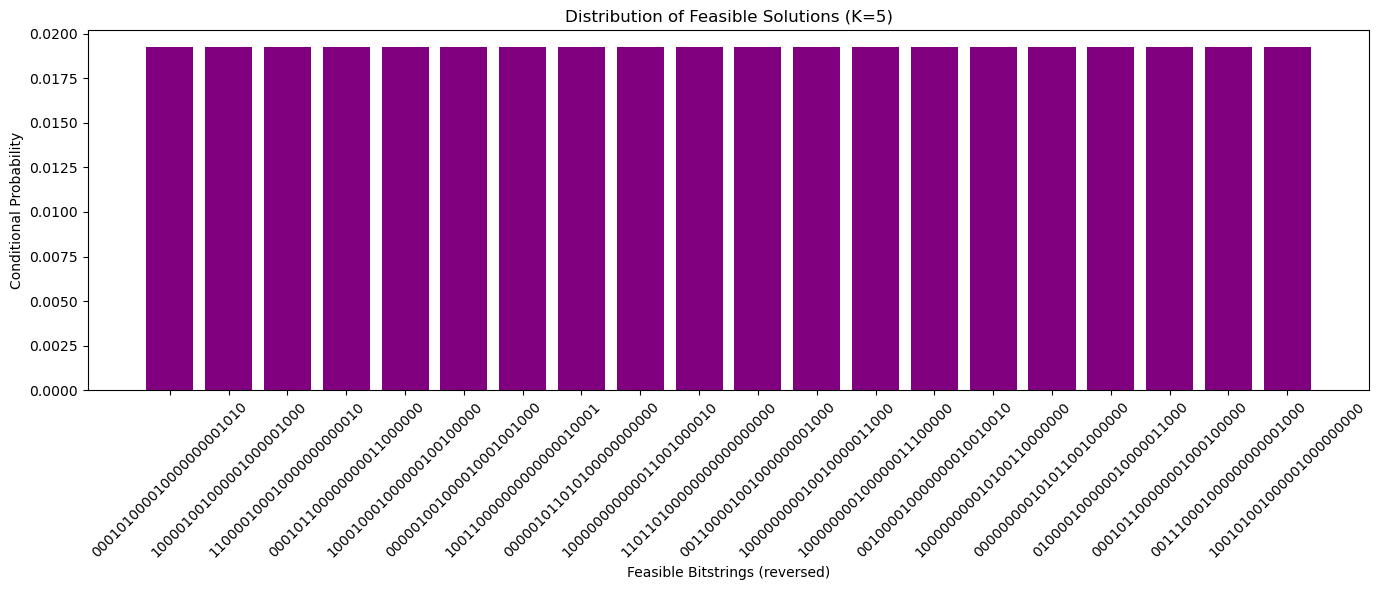

In [28]:
# === Histogram of ONLY feasible solutions (sum(x) == K) ===
import matplotlib.pyplot as plt
import numpy as np

# Total shots
total_shots = sum(counts.values())

# Filter feasible bitstrings
feasible_counts = {}

for bitstr, ct in counts.items():
    x = decode(bitstr)
    if int(x.sum()) == K:
        feasible_counts[bitstr] = ct

# Check if we found feasible solutions
if len(feasible_counts) == 0:
    print("No feasible solutions found in samples.")
else:
    # Normalize probabilities among feasible ones
    feasible_total = sum(feasible_counts.values())
    probs = {b: c / feasible_total for b, c in feasible_counts.items()}
    
    # Sort by probability descending
    sorted_items = sorted(probs.items(), key=lambda x: -x[1])
    
    TOP_M = 20
    sorted_items = sorted_items[:TOP_M]
    
    labels = [b[::-1] for b, _ in sorted_items]
    values = [p for _, p in sorted_items]
    
    plt.figure(figsize=(14, 6))
    plt.bar(labels, values, color="purple")
    plt.xticks(rotation=45)
    plt.ylabel("Conditional Probability")
    plt.xlabel("Feasible Bitstrings (reversed)")
    plt.title(f"Distribution of Feasible Solutions (K={K})")
    plt.tight_layout()
    plt.show()

In [29]:
# REPORT
print("Used n =", n, "K =", K, "rho =", rho, "reps =", reps)
print("Best bitstring:", best_bitstr)
print("Selected count:", int(x.sum()), "(target K =", K, ")")
print("Selected indices (within df_small):", selected_idx.tolist())
print("Sum individual value:", val)
print("Network synergy term:", lam * syn)
print("Total (value + synergy):", total)

# show selected rows 
display(df.loc[selected_idx].reset_index(drop=True))

Used n = 24 K = 5 rho = 26411.02345623568 reps = 2
Best bitstring: 010000000000010001000011
Selected count: 10 (target K = 5 )
Selected indices (within df_small): [0, 1, 6, 10, 22]
Sum individual value: 846.405889857851
Network synergy term: 479.30710613873754
Total (value + synergy): 1325.7129959965885


,case_id,claim_type,region_id,claim_amount,policy_age_days,prior_claims,complexity,review_minutes,broker_id,garage_id,device_id,entity_risk_score,p_fraud,ring_id_latent,severity_L,review_cost,v_i
0,0,auto,0,18081.134056,1613,1,1.093699,66,9,11,13,-0.142785,0.117113,0,5424.340217,66.0,283.394320
1,1,auto,5,3369.652871,1604,2,0.637521,58,3,1,26,0.307181,0.106442,0,1010.895861,58.0,1.180824
2,6,auto,0,8133.888356,2629,0,0.686846,44,3,5,17,-0.026453,0.107112,3,2440.166507,44.0,99.753894
3,10,auto,0,14539.301654,609,2,0.793253,63,3,11,5,-0.011721,0.246446,3,4361.790496,63.0,528.220469
4,22,auto,4,1533.607158,2641,2,1.223137,78,1,11,31,-0.271062,0.046855,0,460.082148,78.0,-66.143617


### Run on real hardware (QPU)

In [31]:
import qiskit
import time
from qbraid import QbraidProvider

# 1. Connect to qBraid
provider = QbraidProvider()
device = provider.get_device("aws:aws:sim:sv1") 
# 2. Convert & Submit (The Bypass Method)
# This sends your N=24 circuit to the cloud for heavy processing
qasm3_program = qiskit.qasm3.dumps(qc)
job = device.run(qasm3_program, shots=5000)


print(f"Job ID: {job.id}")
while str(job.status()) != "JobStatus.COMPLETED":
    print(f"\nFinal Job Status:{job.status()}:")
    time.sleep(2)

counts = job.result().measurement_counts()


Job ID: aws:aws:sim:sv1-847f-qjob-69a400cd48b617208653e140

Final Job Status:JobStatus.INITIALIZING:

Final Job Status:JobStatus.INITIALIZING:

Final Job Status:JobStatus.INITIALIZING:

Final Job Status:JobStatus.QUEUED:

Final Job Status:JobStatus.RUNNING:

Final Job Status:JobStatus.RUNNING:


/var/folders/cj/f8m9tbbs3vb8d8kj0466gdlc0000gn/T/ipykernel_3970/1047596339.py:19: DeprecationWarning: Call to deprecated function measurement_counts. Use 'Result.data.get_counts()' instead.
  counts = job.result().measurement_counts()


In [32]:
# 5) DECODE + pick BEST FEASIBLE (for QPU)
best_feasible = None
best_feasible_score = -1e18

# search feasible bitstrings among measured samples
for bitstr, ct in counts.items():
    x = decode(bitstr)
    if int(x.sum()) == K:
        total, val, syn = score_business(x)
        if total > best_feasible_score:
            best_feasible_score = total
            best_feasible = (bitstr, x, val, syn)

# fallback: if no feasible found, take most frequent
if best_feasible is None:
    best_bitstr = max(counts, key=counts.get)
    x = decode(best_bitstr)
    total, val, syn = score_business(x)
else:
    best_bitstr, x, val, syn = best_feasible
    total = val + lam * syn

selected_idx = np.where(x == 1)[0]

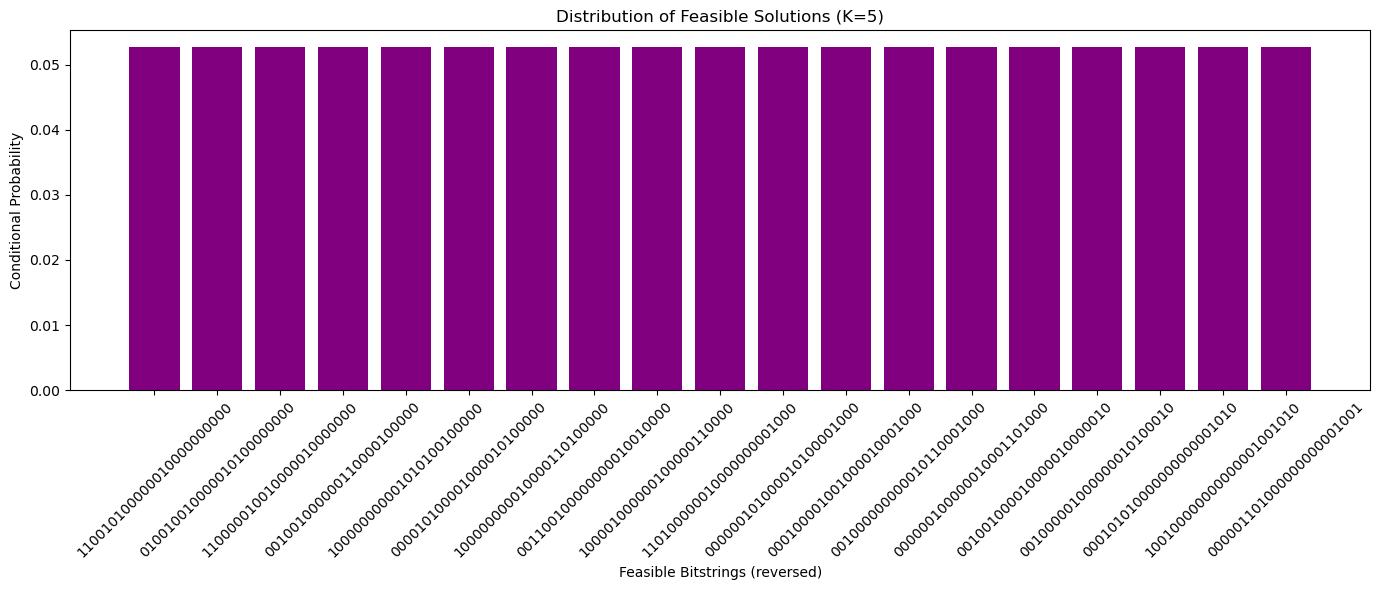

In [33]:
# Total shots
total_shots = sum(counts.values())

# Filter feasible bitstrings
feasible_counts = {}

for bitstr, ct in counts.items():
    x = decode(bitstr)
    if int(x.sum()) == K:
        feasible_counts[bitstr] = ct

# Check if we found feasible solutions
if len(feasible_counts) == 0:
    print("No feasible solutions found in samples.")
else:
    # Normalize probabilities among feasible ones
    feasible_total = sum(feasible_counts.values())
    probs = {b: c / feasible_total for b, c in feasible_counts.items()}
    
    # Sort by probability descending
    sorted_items = sorted(probs.items(), key=lambda x: -x[1])
    
    TOP_M = 20
    sorted_items = sorted_items[:TOP_M]
    
    labels = [b[::-1] for b, _ in sorted_items]
    values = [p for _, p in sorted_items]
    
    plt.figure(figsize=(14, 6))
    plt.bar(labels, values, color="purple")
    plt.xticks(rotation=45)
    plt.ylabel("Conditional Probability")
    plt.xlabel("Feasible Bitstrings (reversed)")
    plt.title(f"Distribution of Feasible Solutions (K={K})")
    plt.tight_layout()
    plt.show()

In [34]:
# REPORT
print("Used n =", n, "K =", K, "rho =", rho, "reps =", reps)
print("Best bitstring:", best_bitstr)
print("Selected count:", int(x.sum()), "(target K =", K, ")")
print("Selected indices (within df_small):", selected_idx.tolist())
print("Sum individual value:", val)
print("Network synergy term:", lam * syn)
print("Total (value + synergy):", total)

# show selected rows 
display(df.loc[selected_idx].reset_index(drop=True))

Used n = 24 K = 5 rho = 26411.02345623568 reps = 2
Best bitstring: 000100000000010000001011
Selected count: 16 (target K = 5 )
Selected indices (within df_small): [0, 1, 3, 10, 20]
Sum individual value: 1319.7899940025984
Network synergy term: 402.5536096668579
Total (value + synergy): 1722.3436036694563


,case_id,claim_type,region_id,claim_amount,policy_age_days,prior_claims,complexity,review_minutes,broker_id,garage_id,device_id,entity_risk_score,p_fraud,ring_id_latent,severity_L,review_cost,v_i
0,0,auto,0,18081.134056,1613,1,1.093699,66,9,11,13,-0.142785,0.117113,0,5424.340217,66.0,283.394320
1,1,auto,5,3369.652871,1604,2,0.637521,58,3,1,26,0.307181,0.106442,0,1010.895861,58.0,1.180824
2,3,auto,0,11738.840843,2027,2,1.326051,82,3,8,7,0.308957,0.278471,3,3521.652253,82.0,457.373428
3,10,auto,0,14539.301654,609,2,0.793253,63,3,11,5,-0.011721,0.246446,3,4361.790496,63.0,528.220469
4,20,auto,4,7442.964681,2450,0,1.412094,69,6,5,26,-0.109665,0.096590,2,2232.889404,69.0,49.620953


# New code tuning the mixer

In [14]:
import numpy as np
from scipy.optimize import minimize
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit_aer.primitives import Estimator as AerEstimator
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import RXXGate, RYYGate, RZZGate
import time

print("🚀 Starting constrained QAOA...")

# ============================================================
# 1) Feasible initial state
# ============================================================
def random_initial_state_weight_k(n, K, seed=0):
    rng = np.random.default_rng(seed)
    ones = rng.choice(n, size=K, replace=False)
    qc0 = QuantumCircuit(n)
    for i in ones:
        qc0.x(int(i))
    return qc0, np.sort(ones)


# ============================================================
# 2) Mixer graphs
# ============================================================
def ring_edges(n):
    return [(i, (i + 1) % n) for i in range(n)]

def edges_from_W(W, top_m=80):
    n = W.shape[0]
    pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            if W[i, j] != 0:
                pairs.append((abs(W[i, j]), i, j))
    pairs.sort(reverse=True)
    return {(i, j) for _, i, j in pairs[:top_m]}


# ============================================================
# 3) XY mixer
# ============================================================
def apply_xy_mixer_layer(qc, beta, edges):
    for (i, j) in edges:
        qc.append(RXXGate(2 * beta), [i, j])
        qc.append(RYYGate(2 * beta), [i, j])


# ============================================================
# 4) Cost layer
# ============================================================
def apply_cost_layer(qc, gamma, H):
    for pauli, coeff in H.to_list():
        coeff = float(np.real(coeff))
        if abs(coeff) < 1e-12:
            continue
        z_idx = [q for q, p in enumerate(pauli[::-1]) if p == "Z"]
        if len(z_idx) == 1:
            qc.rz(2 * gamma * coeff, z_idx[0])
        elif len(z_idx) == 2:
            i, j = z_idx
            qc.append(RZZGate(2 * gamma * coeff), [i, j])


# ============================================================
# 5) Template circuit
# ============================================================
def constrained_qaoa_template(H, n, qc0, gammas, betas, edges):
    qc = QuantumCircuit(n)
    qc.compose(qc0, inplace=True)

    for layer in range(len(gammas)):
        apply_cost_layer(qc, gammas[layer], H)
        apply_xy_mixer_layer(qc, betas[layer], edges)

    return qc

# ============================================================
# ===================== RUN =====================
# ============================================================

# print("📦 Building Ising Hamiltonian...")
# H, offset = qubo.to_ising()

print("🔗 Building mixer graph...")
base = set(tuple(sorted(e)) for e in ring_edges(n))
extra = edges_from_W(W, top_m=80)
edges = sorted(base | extra)
print("Number of mixer edges:", len(edges))

p = 3
gammas = ParameterVector("gamma", p)
betas  = ParameterVector("beta", p)

qc0, ones0 = random_initial_state_weight_k(n, K, seed=42)
print("Initial ones:", ones0.tolist())

print("🧱 Building circuit template...")
qc_template = constrained_qaoa_template(H, n, qc0, gammas, betas, edges)
print("Circuit depth:", qc_template.depth())

print("⚙️ Creating estimator...")
estimator = AerEstimator(run_options={"shots": 3000, "seed": 123})

# ------------------------------------------------------------
# Optimization with progress printing
# ------------------------------------------------------------
call_counter = {"n": 0}
start_time = time.time()

def energy_shots(theta):
    call_counter["n"] += 1

    g = theta[:p]
    b = theta[p:]

    bind = {gammas[i]: g[i] for i in range(p)}
    bind.update({betas[i]: b[i] for i in range(p)})

    qc = qc_template.assign_parameters(bind, inplace=False)
    val = float(estimator.run([qc], [H]).result().values[0])

    if call_counter["n"] % 10 == 0:
        elapsed = time.time() - start_time
        print(f"   Eval {call_counter['n']} | E = {val:.4f} | time = {elapsed:.1f}s")

    return val


print("🔍 Starting optimization...")
theta0 = np.random.default_rng(0).uniform(0, 2*np.pi, size=2*p)

opt = minimize(
    energy_shots,
    theta0,
    method="COBYLA",
    options={"maxiter": 150}
)

theta_star = opt.x
print("✅ Optimization finished.")
print("Total evaluations:", call_counter["n"])
print("Best energy:", opt.fun)

# ------------------------------------------------------------
# Sampling
# ------------------------------------------------------------
print("🎯 Sampling optimized circuit...")

bind_star = {gammas[i]: theta_star[i] for i in range(p)}
bind_star.update({betas[i]: theta_star[p+i] for i in range(p)})

qc_opt = qc_template.assign_parameters(bind_star, inplace=False)
qc_opt.measure_all()

backend = Aer.get_backend("aer_simulator")
tqc = transpile(qc_opt, backend)

counts = backend.run(tqc, shots=8000, seed_simulator=123).result().get_counts()

print("Sampling done.")
print("Number of distinct states observed:", len(counts))

🚀 Starting constrained QAOA...
📦 Building Ising Hamiltonian...
🔗 Building mixer graph...
Number of mixer edges: 69
Initial ones: [1, 10, 14, 16, 23]
🧱 Building circuit template...
Circuit depth: 196
⚙️ Creating estimator...
🔍 Starting optimization...


/Users/gaspardlafont/opt/anaconda3/envs/qutip-env/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3699: DeprecationWarning: Estimator has been deprecated as of Aer 0.15, please use EstimatorV2 instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/gaspardlafont/opt/anaconda3/envs/qutip-env/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3699: DeprecationWarning: Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/gaspardlafont/opt/anaconda3/envs/qutip-env/lib/python3.11/site-packages/qiskit_aer/primitives/estimator.py:583: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  layout = [bit_map[q

   Eval 10 | E = -1451275.6788 | time = 130.0s
   Eval 20 | E = -1451438.6022 | time = 273.6s
   Eval 30 | E = -1451436.0156 | time = 418.2s
   Eval 40 | E = -1451493.6008 | time = 558.6s
   Eval 50 | E = -1451492.3498 | time = 693.8s
   Eval 60 | E = -1451506.9881 | time = 829.3s
✅ Optimization finished.
Total evaluations: 66
Best energy: -1451510.685670223
🎯 Sampling optimized circuit...
Sampling done.
Number of distinct states observed: 1256


best_bitstr (Qiskit order): 000000000000010100001101
Appearances: 2 out of 8000
Probability: 0.00025
Hamming weight: 5  expected K: 5
business total: 2065.358023711785
value: 1222.517370611983
synergy: 842.8406530998018
selected_idx: [ 0  2  3  8 10]


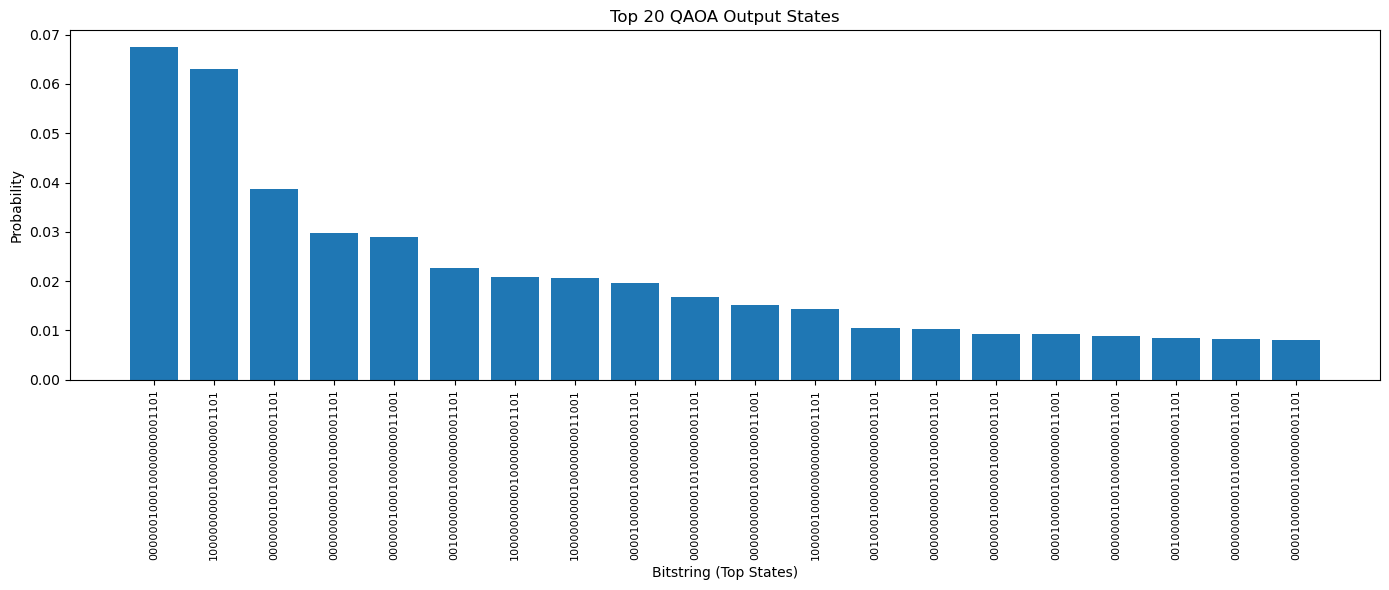

In [15]:
# ============================================================
# Helpers: decode + business score
# ============================================================
def bitstr_to_x(bitstr, n):
    # Qiskit prints MSB..LSB, where LSB corresponds to qubit 0
    return np.array([int(b) for b in bitstr[::-1]], dtype=int)[:n]

def score_business(x, v, W, lam):
    val = float(np.sum(v * x))
    syn = float(np.sum(np.triu(W, 1) * np.outer(x, x)))  # fast sum_{i<j} W_ij x_i x_j
    total = val + lam * syn
    return total, val, syn

# Pick BEST among observed (feasible) samples by BUSINESS score
best = None
best_total = -1e18
shots = sum(counts.values())

for bitstr, ct in counts.items():
    x = bitstr_to_x(bitstr, n)

    # should always be feasible with XY mixer + feasible initial state; keep for safety
    if int(x.sum()) != K:
        continue

    total, val, syn = score_business(x, v, W, lam)
    if total > best_total:
        best_total = total
        best = (bitstr, x, ct, total, val, syn)

if best is None:
    raise RuntimeError("No feasible bitstrings found. (Unexpected with XY mixer.)")

best_bitstr, x_best, ct_best, total_best, val_best, syn_best = best
selected_idx = np.where(x_best == 1)[0]

# print("best_bitstr (Qiskit order):", best_bitstr)
# print("prob:", ct_best / shots)
# print("Hamming weight:", int(x_best.sum()), " expected K:", K)
# print("business total:", total_best, "value:", val_best, "synergy:", syn_best)
# print("selected_idx:", selected_idx)

print("best_bitstr (Qiskit order):", best_bitstr)
print("Appearances:", ct_best, "out of", shots)
print("Probability:", round(ct_best / shots, 6))
print("Hamming weight:", int(x_best.sum()), " expected K:", K)
print("business total:", total_best)
print("value:", val_best)
print("synergy:", syn_best)
print("selected_idx:", selected_idx)

import numpy as np
import matplotlib.pyplot as plt

# --- Convert counts -> probabilities ---
shots = sum(counts.values())

data = []
for bitstr, ct in counts.items():
    prob = ct / shots
    
    # reverse to match x_0 ... x_{n-1}
    x = bitstr[::-1]
    
    weight = x.count("1")
    data.append((bitstr, prob, weight))

# --- Sort by probability descending ---
data.sort(key=lambda x: -x[1])

bitstrings = [d[0] for d in data]
probs = [d[1] for d in data]
weights = [d[2] for d in data]

# --- Plot ---
top_k = 20
plt.figure(figsize=(14,6))
plt.bar(range(top_k), probs[:top_k])

plt.xticks(
    range(top_k),
    bitstrings[:top_k],
    rotation=90,
    fontsize=8
)

plt.ylabel("Probability")
plt.xlabel("Bitstring (Top States)")
plt.title(f"Top {top_k} QAOA Output States")
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

shots = sum(counts.values())

rows = []

for bitstr, ct in counts.items():
    x = bitstr_to_x(bitstr, n)
    weight = int(x.sum())
    prob = ct / shots
    
    total, val, syn = score_business(x, v, W, lam)

    rows.append({
        "bitstring": bitstr,
        "appearances": ct,
        "probability": prob,
        "hamming_weight": weight,
        "business_total": total,
        "value": val,
        "synergy": syn
    })

# Create DataFrame
df_results = pd.DataFrame(rows)

# Sort by appearances descending
df_results = df_results.sort_values(by="appearances", ascending=False)

# Display full table
display(df_results)

,bitstring,appearances,probability,hamming_weight,business_total,value,synergy
1231,000000100010000000001101,540,0.067500,5,757.502147,648.321772,109.180375
1156,100000000010000000001101,504,0.063000,5,765.164979,655.984604,109.180375
1099,000000010010000000001101,310,0.038750,5,889.984007,700.783912,189.200095
561,000000000010001000001101,238,0.029750,5,935.704079,826.523704,109.180375
961,000000100010000000011001,231,0.028875,5,729.695294,626.347050,103.348244
...,...,...,...,...,...,...,...
450,011000000010000010000100,1,0.000125,5,96.530766,-157.282617,253.813383
452,100000000000010001001001,1,0.000125,5,1646.104208,1314.811024,331.293184
454,000000010000000101000101,1,0.000125,5,686.287915,327.545589,358.742326
456,010000000000010001010001,1,0.000125,5,1362.391600,807.659204,554.732396


#### Run on real hardware

In [17]:
# 1. Connect to qBraid
provider = QbraidProvider()
device = provider.get_device("aws:aws:sim:sv1") 
# 2. Convert & Submit (The Bypass Method)
# This sends your N=24 circuit to the cloud for heavy processing
qasm3_program = qiskit.qasm3.dumps(qc_opt)
job = device.run(qasm3_program, shots=5000)


print(f"Job ID: {job.id}")
while str(job.status()) != "JobStatus.COMPLETED":
    print(f"\nFinal Job Status:{job.status()}:")
    time.sleep(2)

counts = job.result().measurement_counts()

Job ID: aws:aws:sim:sv1-847f-qjob-69a3f5f148b617208653e0fe

Final Job Status:JobStatus.INITIALIZING:

Final Job Status:JobStatus.INITIALIZING:

Final Job Status:JobStatus.INITIALIZING:

Final Job Status:JobStatus.INITIALIZING:

Final Job Status:JobStatus.INITIALIZING:

Final Job Status:JobStatus.INITIALIZING:

Final Job Status:JobStatus.QUEUED:

Final Job Status:JobStatus.RUNNING:

Final Job Status:JobStatus.RUNNING:

Final Job Status:JobStatus.RUNNING:

Final Job Status:JobStatus.RUNNING:

Final Job Status:JobStatus.RUNNING:

Final Job Status:JobStatus.RUNNING:


/var/folders/cj/f8m9tbbs3vb8d8kj0466gdlc0000gn/T/ipykernel_3970/478170767.py:15: DeprecationWarning: Call to deprecated function measurement_counts. Use 'Result.data.get_counts()' instead.
  counts = job.result().measurement_counts()


best_bitstr (Qiskit order): 000000000000010100001101
Appearances: 2 out of 5000
Probability: 0.0004
Hamming weight: 5  expected K: 5
business total: 2065.358023711785
value: 1222.517370611983
synergy: 842.8406530998018
selected_idx: [ 0  2  3  8 10]


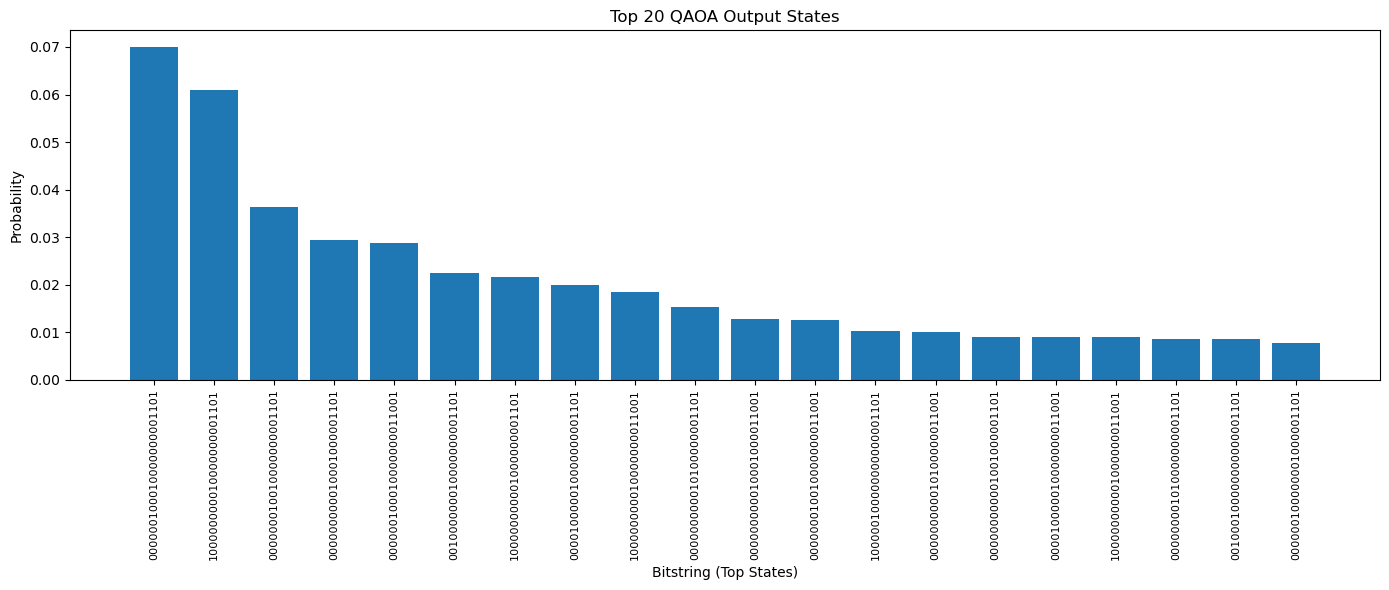

In [18]:
# Pick BEST among observed (feasible) samples by BUSINESS score
best = None
best_total = -1e18
shots = sum(counts.values())

for bitstr, ct in counts.items():
    x = bitstr_to_x(bitstr, n)

    # should always be feasible with XY mixer + feasible initial state; keep for safety
    if int(x.sum()) != K:
        continue

    total, val, syn = score_business(x, v, W, lam)
    if total > best_total:
        best_total = total
        best = (bitstr, x, ct, total, val, syn)

if best is None:
    raise RuntimeError("No feasible bitstrings found. (Unexpected with XY mixer.)")

best_bitstr, x_best, ct_best, total_best, val_best, syn_best = best
selected_idx = np.where(x_best == 1)[0]

# print("best_bitstr (Qiskit order):", best_bitstr)
# print("prob:", ct_best / shots)
# print("Hamming weight:", int(x_best.sum()), " expected K:", K)
# print("business total:", total_best, "value:", val_best, "synergy:", syn_best)
# print("selected_idx:", selected_idx)

print("best_bitstr (Qiskit order):", best_bitstr)
print("Appearances:", ct_best, "out of", shots)
print("Probability:", round(ct_best / shots, 6))
print("Hamming weight:", int(x_best.sum()), " expected K:", K)
print("business total:", total_best)
print("value:", val_best)
print("synergy:", syn_best)
print("selected_idx:", selected_idx)

import numpy as np
import matplotlib.pyplot as plt

# --- Convert counts -> probabilities ---
shots = sum(counts.values())

data = []
for bitstr, ct in counts.items():
    prob = ct / shots
    
    # reverse to match x_0 ... x_{n-1}
    x = bitstr[::-1]
    
    weight = x.count("1")
    data.append((bitstr, prob, weight))

# --- Sort by probability descending ---
data.sort(key=lambda x: -x[1])

bitstrings = [d[0] for d in data]
probs = [d[1] for d in data]
weights = [d[2] for d in data]

# --- Plot ---
top_k = 20
plt.figure(figsize=(14,6))
plt.bar(range(top_k), probs[:top_k])

plt.xticks(
    range(top_k),
    bitstrings[:top_k],
    rotation=90,
    fontsize=8
)

plt.ylabel("Probability")
plt.xlabel("Bitstring (Top States)")
plt.title(f"Top {top_k} QAOA Output States")
plt.tight_layout()
plt.show()

In [19]:
shots = sum(counts.values())

rows = []

for bitstr, ct in counts.items():
    x = bitstr_to_x(bitstr, n)
    weight = int(x.sum())
    prob = ct / shots
    
    total, val, syn = score_business(x, v, W, lam)

    rows.append({
        "bitstring": bitstr,
        "appearances": ct,
        "probability": prob,
        "hamming_weight": weight,
        "business_total": total,
        "value": val,
        "synergy": syn
    })

# Create DataFrame
df_results = pd.DataFrame(rows)

# Sort by appearances descending
df_results = df_results.sort_values(by="appearances", ascending=False)

# Display full table
display(df_results)

,bitstring,appearances,probability,hamming_weight,business_total,value,synergy
285,000000100010000000001101,350,0.0700,5,757.502147,648.321772,109.180375
881,100000000010000000001101,305,0.0610,5,765.164979,655.984604,109.180375
209,000000010010000000001101,182,0.0364,5,889.984007,700.783912,189.200095
77,000000000010001000001101,147,0.0294,5,935.704079,826.523704,109.180375
288,000000100010000000011001,144,0.0288,5,729.695294,626.347050,103.348244
...,...,...,...,...,...,...,...
472,000100000000001000001101,1,0.0002,5,1000.585949,891.405574,109.180375
473,000100000000001000011001,1,0.0002,5,869.430852,869.430852,0.000000
474,000100000000001001000101,1,0.0002,5,736.433384,533.786040,202.647344
475,000100000000001010000101,1,0.0002,5,521.241628,412.061253,109.180375
